In [2]:
# 1. Subir el ZIP desde tu computadora
from google.colab import files
uploaded = files.upload()  # te va a abrir un selector de archivos

Saving wb_data_vis-main.zip to wb_data_vis-main.zip


In [3]:
# 2. Descomprimir
import zipfile
with zipfile.ZipFile('wb_data_vis-main.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# 3. Ir a la carpeta
import os
os.chdir('wb_data_vis-main')

# 4. Verificar que está todo bien
os.listdir()

['uv.lock',
 '.factory',
 '.gitignore',
 '.python-version',
 'pyproject.toml',
 'notebooks',
 'brainstorming.md',
 'data']

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import requests
import pandas as pd
import duckdb
import json
from pathlib import Path
import re
from numpy import char

BASE = "https://data360api.worldbank.org"

def search_indicators(keyword="*", top=20):
    """Buscar indicadores por tema."""
    resp = requests.post(f"{BASE}/data360/searchv2", json={
        "count": False,
        # "filter": f"series_description/topics/any(t: t/name eq '{topic}') and type eq 'indicator'",
        "select": "series_description/idno, series_description/name, series_description/database_id",
        "search": keyword,
        "top": top
    })
    return resp.json()

def get_data_to_parquet(
    database_id,
    indicator,
    countries=None,
    time_from=None,
    time_to=None,
    output_path="../data/raw/data.parquet"
):
    """Fetch paginated API data and stream directly to a parquet file."""
    if database_id is None: return

    params = {"DATABASE_ID": database_id, "INDICATOR": indicator}
    if countries:
        params["REF_AREA"] = countries
    if time_from:
        params["timePeriodFrom"] = time_from
    if time_to:
        params["timePeriodTo"] = time_to

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    con = duckdb.connect()
    con.execute("CREATE TABLE temp (data JSON)")  # staging table

    skip = 0
    table_created = False

    while True:
        params["skip"] = skip
        resp = requests.get(f"{BASE}/data360/data", params=params)
        resp.raise_for_status()
        values = resp.json().get("value", [])

        if not values:
            break

        # Write batch to a temp JSON file DuckDB can read
        tmp_file = Path("/tmp/_batch.json")
        tmp_file.write_text(json.dumps(values))

        if not table_created:
            con.execute(f"""
                CREATE TABLE results AS
                SELECT * FROM read_json_auto('{tmp_file}')
            """)
            table_created = True
        else:
            con.execute(f"""
                INSERT INTO results
                SELECT * FROM read_json_auto('{tmp_file}')
            """)

        if len(values) < 1000:
            break

        skip += 1000

    # Write everything to parquet in one shot
    if table_created:
        con.execute(f"""
            COPY results TO '{output_path}' (FORMAT PARQUET)
        """)
        print(f"Saved to {output_path}")
    else:
        print("No data returned.")

    con.close()

indicators = [
    #'internet','wealth','education','corruption','freedom','development','commerce','trade','corruption','politic', 'fdi','urbanization','human rights',
    'civil society','rule of law', 'press freedom','governance']

for indicator in indicators:
    result = search_indicators(indicator)
    for i in result['value']:
        meta = i['series_description']
        name = "_".join([x.lower() for x in meta['name'].split(' ') if char.isalnum(x) and x not in ['the','of','at','a',]])

        output_file = f'../data/raw/{indicator}/{name}.parquet'
        if Path(output_file).is_file():
            continue
        get_data_to_parquet(meta['database_id'],meta['idno'],output_path=output_file)


Saved to ../data/raw/civil society/core_civil_society_index.parquet
Saved to ../data/raw/civil society/civil_society_participation_index.parquet
Saved to ../data/raw/civil society/women_civil_society_participation_index.parquet
Saved to ../data/raw/civil society/nations_in_civil_society.parquet
Saved to ../data/raw/civil society/bertelsmann_transformation_civil_society_traditions.parquet
Saved to ../data/raw/civil society/access_to_civil_justice.parquet
Saved to ../data/raw/civil society/civil_and_political_inclusion_score.parquet
Saved to ../data/raw/civil society/democracy_civil_liberties_score.parquet
Saved to ../data/raw/civil society/civil_liberties_index.parquet
Saved to ../data/raw/civil society/political_civil_liberties_index.parquet
Saved to ../data/raw/civil society/women_civil_liberties_index.parquet
Saved to ../data/raw/civil society/criminal_penalties_or_civil_remedies_exist_for_sexual_harassment_in_employment.parquet
Saved to ../data/raw/civil society/civic_space_index.pa

In [7]:
import pandas as pd
from pathlib import Path
from functools import reduce

BASE = Path("/content/wb_data_vis-main/data/raw")

INDICES = {
    "Control Corrupción":    BASE / "corruption/control_corruption:_percentile_rank.parquet",
    "Corrupción Política":   BASE / "corruption/political_corruption_index.parquet",
    "Corrupción Sector Púb": BASE / "corruption/public_sector_corruption_index.parquet",
    "Libertad de Prensa":    BASE / "press freedom/press_freedom_index_score.parquet",
    "Estado de Derecho":     BASE / "rule of law/wjp_rule_law_overall_score.parquet",
    "Libertades Civiles":    BASE / "freedom/freedom_house:_civil_liberties_score_(maximum_score_=_60).parquet",
    "Score Freedom Total":   BASE / "freedom/freedom_house:_total_freedom_score_(maximum_score_=_100).parquet",
    "Soc. Civil Participac": BASE / "civil society/civil_society_participation_index.parquet",
    "Soc. Civil (Core)":     BASE / "civil society/core_civil_society_index.parquet",
}

PAISES = ["ARG", "BRA", "CHL", "URY", "PRY", "BOL", "PER", "COL", "MEX"]

dfs = []
for nombre, path in INDICES.items():
    try:
        df = pd.read_parquet(path)
        df = df[df["REF_AREA"].isin(PAISES)][["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
        df = df.rename(columns={"OBS_VALUE": nombre})
        dfs.append(df)
        print(f"✅ {nombre} — {len(df)} filas")
    except Exception as e:
        print(f"⚠️  {nombre}: {e}")

merged = reduce(lambda a, b: pd.merge(a, b, on=["REF_AREA", "TIME_PERIOD"], how="outer"), dfs)
merged["TIME_PERIOD"] = merged["TIME_PERIOD"].astype(int)
merged = merged.sort_values(["REF_AREA", "TIME_PERIOD"]).reset_index(drop=True)

print(f"\nShape final: {merged.shape}")
merged.head(10)

✅ Control Corrupción — 225 filas
✅ Corrupción Política — 2030 filas
✅ Corrupción Sector Púb — 2030 filas
✅ Libertad de Prensa — 207 filas
✅ Estado de Derecho — 92 filas
✅ Libertades Civiles — 108 filas
✅ Score Freedom Total — 108 filas
✅ Soc. Civil Participac — 2030 filas
✅ Soc. Civil (Core) — 1998 filas

Shape final: (2039, 11)


,REF_AREA,TIME_PERIOD,Control Corrupción,Corrupción Política,Corrupción Sector Púb,Libertad de Prensa,Estado de Derecho,Libertades Civiles,Score Freedom Total,Soc. Civil Participac,Soc. Civil (Core)
0,ARG,1789,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
1,ARG,1790,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
2,ARG,1791,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
3,ARG,1792,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
4,ARG,1793,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
5,ARG,1794,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
6,ARG,1795,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
7,ARG,1796,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
8,ARG,1797,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
9,ARG,1798,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431


In [8]:
# ¿Cuántos valores tiene cada índice para cada país?
cobertura = merged.groupby("REF_AREA")[list(INDICES.keys())].count()
print(cobertura.to_string())

          Control Corrupción  Corrupción Política  Corrupción Sector Púb  Libertad de Prensa  Estado de Derecho  Libertades Civiles  Score Freedom Total  Soc. Civil Participac  Soc. Civil (Core)
REF_AREA                                                                                                                                                                                          
ARG                       25                  236                    236                  23                 11                  12                   12                    236                236
BOL                       25                  200                    200                  23                 11                  12                   12                    200                200
BRA                       25                  236                    236                  23                 11                  12                   12                    236                236
CHL                      

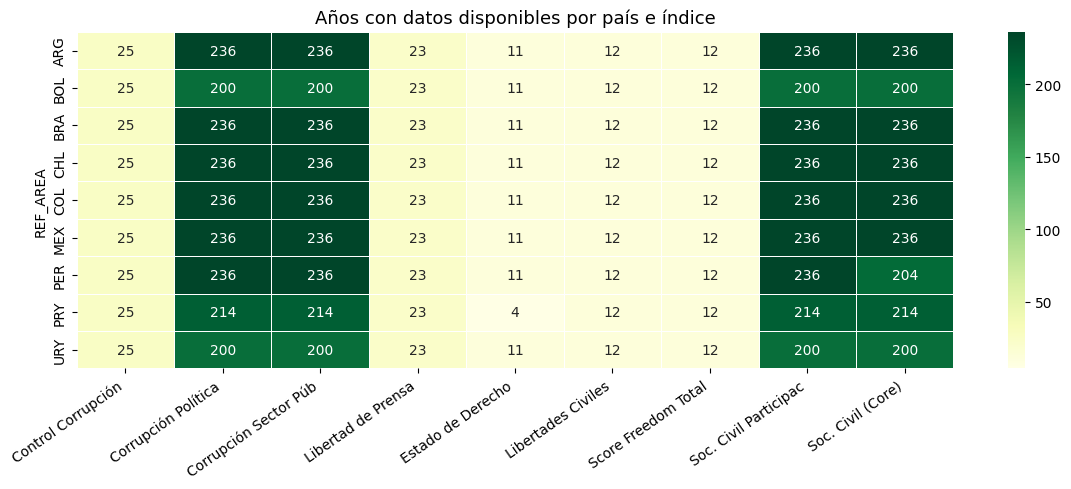

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cobertura,
    annot=True, fmt="d",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Años con datos disponibles por país e índice", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Ver qué columnas extra tienen los de muchas filas
df_test = pd.read_parquet(BASE / "corruption/political_corruption_index.parquet")
df_test[df_test["REF_AREA"] == "ARG"][["REF_AREA","TIME_PERIOD","SEX","AGE","URBANISATION","OBS_VALUE"]].head(20)

,REF_AREA,TIME_PERIOD,SEX,AGE,URBANISATION,OBS_VALUE
5291,ARG,1789,_T,_T,_T,0.321
5292,ARG,1790,_T,_T,_T,0.321
5293,ARG,1791,_T,_T,_T,0.321
5294,ARG,1792,_T,_T,_T,0.321
5295,ARG,1793,_T,_T,_T,0.321
5296,ARG,1794,_T,_T,_T,0.321
5297,ARG,1795,_T,_T,_T,0.321
5298,ARG,1796,_T,_T,_T,0.321
5299,ARG,1797,_T,_T,_T,0.321
5300,ARG,1798,_T,_T,_T,0.321


In [11]:
dfs = []
for nombre, path in INDICES.items():
    try:
        df = pd.read_parquet(path)

        # Filtrar solo filas agregadas (sin desagregación)
        for col in ["SEX", "AGE", "URBANISATION"]:
            if col in df.columns:
                df = df[df[col] == "_T"]

        df = df[df["REF_AREA"].isin(PAISES)][["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]

        # Si aún hay duplicados por año, quedarse con el promedio
        df = df.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].mean()

        df = df.rename(columns={"OBS_VALUE": nombre})
        dfs.append(df)
        print(f"✅ {nombre} — {len(df)} filas")
    except Exception as e:
        print(f"⚠️  {nombre}: {e}")

merged = reduce(lambda a, b: pd.merge(a, b, on=["REF_AREA", "TIME_PERIOD"], how="outer"), dfs)
merged["TIME_PERIOD"] = merged["TIME_PERIOD"].astype(int)
merged = merged.sort_values(["REF_AREA", "TIME_PERIOD"]).reset_index(drop=True)
print(f"\nShape final: {merged.shape}")
merged.head(10)

⚠️  Control Corrupción: agg function failed [how->mean,dtype->object]
⚠️  Corrupción Política: agg function failed [how->mean,dtype->object]
⚠️  Corrupción Sector Púb: agg function failed [how->mean,dtype->object]
✅ Libertad de Prensa — 0 filas
⚠️  Estado de Derecho: agg function failed [how->mean,dtype->object]
⚠️  Libertades Civiles: agg function failed [how->mean,dtype->object]
✅ Score Freedom Total — 0 filas
⚠️  Soc. Civil Participac: agg function failed [how->mean,dtype->object]
⚠️  Soc. Civil (Core): agg function failed [how->mean,dtype->object]

Shape final: (0, 4)


,REF_AREA,TIME_PERIOD,Libertad de Prensa,Score Freedom Total


In [12]:
# Diagnóstico rápido de un archivo
df_test = pd.read_parquet(BASE / "corruption/political_corruption_index.parquet")
df_test_arg = df_test[df_test["REF_AREA"] == "ARG"]

print("Dtype OBS_VALUE:", df_test_arg["OBS_VALUE"].dtype)
print("\nValores únicos SEX:", df_test_arg["SEX"].unique() if "SEX" in df_test_arg.columns else "no existe")
print("Valores únicos AGE:", df_test_arg["AGE"].unique() if "AGE" in df_test_arg.columns else "no existe")
print("Valores únicos URBANISATION:", df_test_arg["URBANISATION"].unique() if "URBANISATION" in df_test_arg.columns else "no existe")
print("\nEjemplo de filas:")
df_test_arg[["TIME_PERIOD","SEX","AGE","URBANISATION","OBS_VALUE"]].head(10)

Dtype OBS_VALUE: object

Valores únicos SEX: ['_T']
Valores únicos AGE: ['_T']
Valores únicos URBANISATION: ['_T']

Ejemplo de filas:


,TIME_PERIOD,SEX,AGE,URBANISATION,OBS_VALUE
5291,1789,_T,_T,_T,0.321
5292,1790,_T,_T,_T,0.321
5293,1791,_T,_T,_T,0.321
5294,1792,_T,_T,_T,0.321
5295,1793,_T,_T,_T,0.321
5296,1794,_T,_T,_T,0.321
5297,1795,_T,_T,_T,0.321
5298,1796,_T,_T,_T,0.321
5299,1797,_T,_T,_T,0.321
5300,1798,_T,_T,_T,0.321


In [13]:
dfs = []
for nombre, path in INDICES.items():
    try:
        df = pd.read_parquet(path)
        df = df[df["REF_AREA"].isin(PAISES)][["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]

        # Convertir OBS_VALUE a número
        df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
        df = df.dropna(subset=["OBS_VALUE"])

        # Eliminar duplicados por año si los hay
        df = df.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].mean()
        df = df.rename(columns={"OBS_VALUE": nombre})

        dfs.append(df)
        print(f"✅ {nombre} — {len(df)} filas, años: {df['TIME_PERIOD'].min()}–{df['TIME_PERIOD'].max()}")
    except Exception as e:
        print(f"⚠️  {nombre}: {e}")

merged = reduce(lambda a, b: pd.merge(a, b, on=["REF_AREA", "TIME_PERIOD"], how="outer"), dfs)
merged["TIME_PERIOD"] = merged["TIME_PERIOD"].astype(int)
merged = merged.sort_values(["REF_AREA", "TIME_PERIOD"]).reset_index(drop=True)
print(f"\nShape final: {merged.shape}")
merged.head(10)

✅ Control Corrupción — 225 filas, años: 1996–2023
✅ Corrupción Política — 1998 filas, años: 1789–2024
✅ Corrupción Sector Púb — 1998 filas, años: 1789–2024
✅ Libertad de Prensa — 207 filas, años: 2002–2025
✅ Estado de Derecho — 92 filas, años: 2013–2024
✅ Libertades Civiles — 108 filas, años: 2013–2024
✅ Score Freedom Total — 108 filas, años: 2013–2024
✅ Soc. Civil Participac — 1998 filas, años: 1789–2024
✅ Soc. Civil (Core) — 1998 filas, años: 1789–2024

Shape final: (2007, 11)


,REF_AREA,TIME_PERIOD,Control Corrupción,Corrupción Política,Corrupción Sector Púb,Libertad de Prensa,Estado de Derecho,Libertades Civiles,Score Freedom Total,Soc. Civil Participac,Soc. Civil (Core)
0,ARG,1789,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
1,ARG,1790,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
2,ARG,1791,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
3,ARG,1792,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
4,ARG,1793,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
5,ARG,1794,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
6,ARG,1795,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
7,ARG,1796,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
8,ARG,1797,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431
9,ARG,1798,NaN,0.321,0.259,NaN,NaN,NaN,NaN,0.144,0.431


In [14]:
# Filtrar a la ventana común
merged_clean = merged[merged["TIME_PERIOD"].between(2013, 2023)].copy()

print(f"Shape filtrado: {merged_clean.shape}")
print(f"\nNaN por columna:")
print(merged_clean[list(INDICES.keys())].isna().sum().sort_values())

Shape filtrado: (99, 11)

NaN por columna:
Control Corrupción        0
Corrupción Política       0
Corrupción Sector Púb     0
Libertad de Prensa        0
Libertades Civiles        0
Score Freedom Total       0
Soc. Civil Participac     0
Soc. Civil (Core)         0
Estado de Derecho        16
dtype: int64


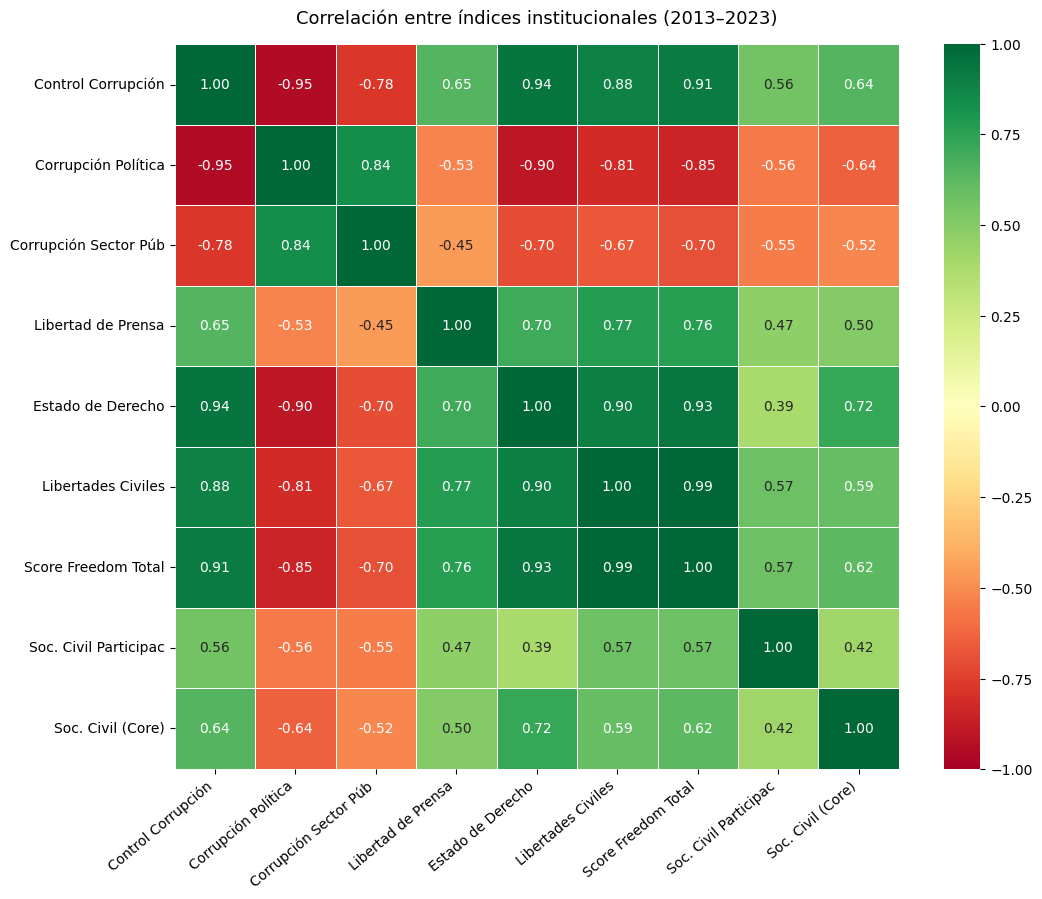

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = list(INDICES.keys())
corr = merged_clean[cols].corr(method="pearson", min_periods=10)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title("Correlación entre índices institucionales (2013–2023)", fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

# **Vamos a correr un análisis para los países de Europa en pos de entender si las correlaciones son similares o no.**

In [16]:
# Ver todos los países disponibles en uno de los archivos con buena cobertura
df_test = pd.read_parquet(BASE / "corruption/control_corruption:_percentile_rank.parquet")
df_test["OBS_VALUE"] = pd.to_numeric(df_test["OBS_VALUE"], errors="coerce")
df_test = df_test.dropna(subset=["OBS_VALUE"])

todos_paises = sorted(df_test["REF_AREA"].unique())
print(f"Total países disponibles: {len(todos_paises)}")
print(todos_paises)

Total países disponibles: 205
['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FRA', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL', 'GTM', 'GUM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAC', 'MAR', 'MCO', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER', 'NGA', 'NIC', 'NLD', 'NOR', 'NP

In [17]:
PAISES_EU = [
    "DEU", "FRA", "ESP", "ITA", "PRT",  # Europa Occidental
    "SWE", "NOR", "DNK", "FIN",          # Nórdicos
    "POL", "HUN", "CZE", "ROU",          # Europa del Este
    "GRC", "HRV", "SVN",                 # Sur/Balcanes
    "GBR", "NLD", "AUT", "BEL",          # También disponibles
]

dfs_eu = []
for nombre, path in INDICES.items():
    try:
        df = pd.read_parquet(path)
        df = df[df["REF_AREA"].isin(PAISES_EU)][["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
        df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
        df = df.dropna(subset=["OBS_VALUE"])
        df = df.groupby(["REF_AREA", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].mean()
        df = df.rename(columns={"OBS_VALUE": nombre})
        dfs_eu.append(df)
        print(f"✅ {nombre} — {len(df)} filas")
    except Exception as e:
        print(f"⚠️  {nombre}: {e}")

merged_eu = reduce(lambda a, b: pd.merge(a, b, on=["REF_AREA", "TIME_PERIOD"], how="outer"), dfs_eu)
merged_eu["TIME_PERIOD"] = merged_eu["TIME_PERIOD"].astype(int)
merged_eu_clean = merged_eu[merged_eu["TIME_PERIOD"].between(2013, 2023)].copy()
merged_eu_clean = merged_eu_clean.sort_values(["REF_AREA", "TIME_PERIOD"]).reset_index(drop=True)

print(f"\nShape final: {merged_eu_clean.shape}")
print(f"NaN por columna:\n{merged_eu_clean[list(INDICES.keys())].isna().sum().sort_values()}")

✅ Control Corrupción — 500 filas
✅ Corrupción Política — 3792 filas
✅ Corrupción Sector Púb — 3904 filas
✅ Libertad de Prensa — 460 filas
✅ Estado de Derecho — 220 filas
✅ Libertades Civiles — 240 filas
✅ Score Freedom Total — 240 filas
✅ Soc. Civil Participac — 3885 filas
✅ Soc. Civil (Core) — 3914 filas

Shape final: (220, 11)
NaN por columna:
Control Corrupción        0
Corrupción Política       0
Corrupción Sector Púb     0
Libertad de Prensa        0
Libertades Civiles        0
Score Freedom Total       0
Soc. Civil Participac     0
Soc. Civil (Core)         0
Estado de Derecho        20
dtype: int64


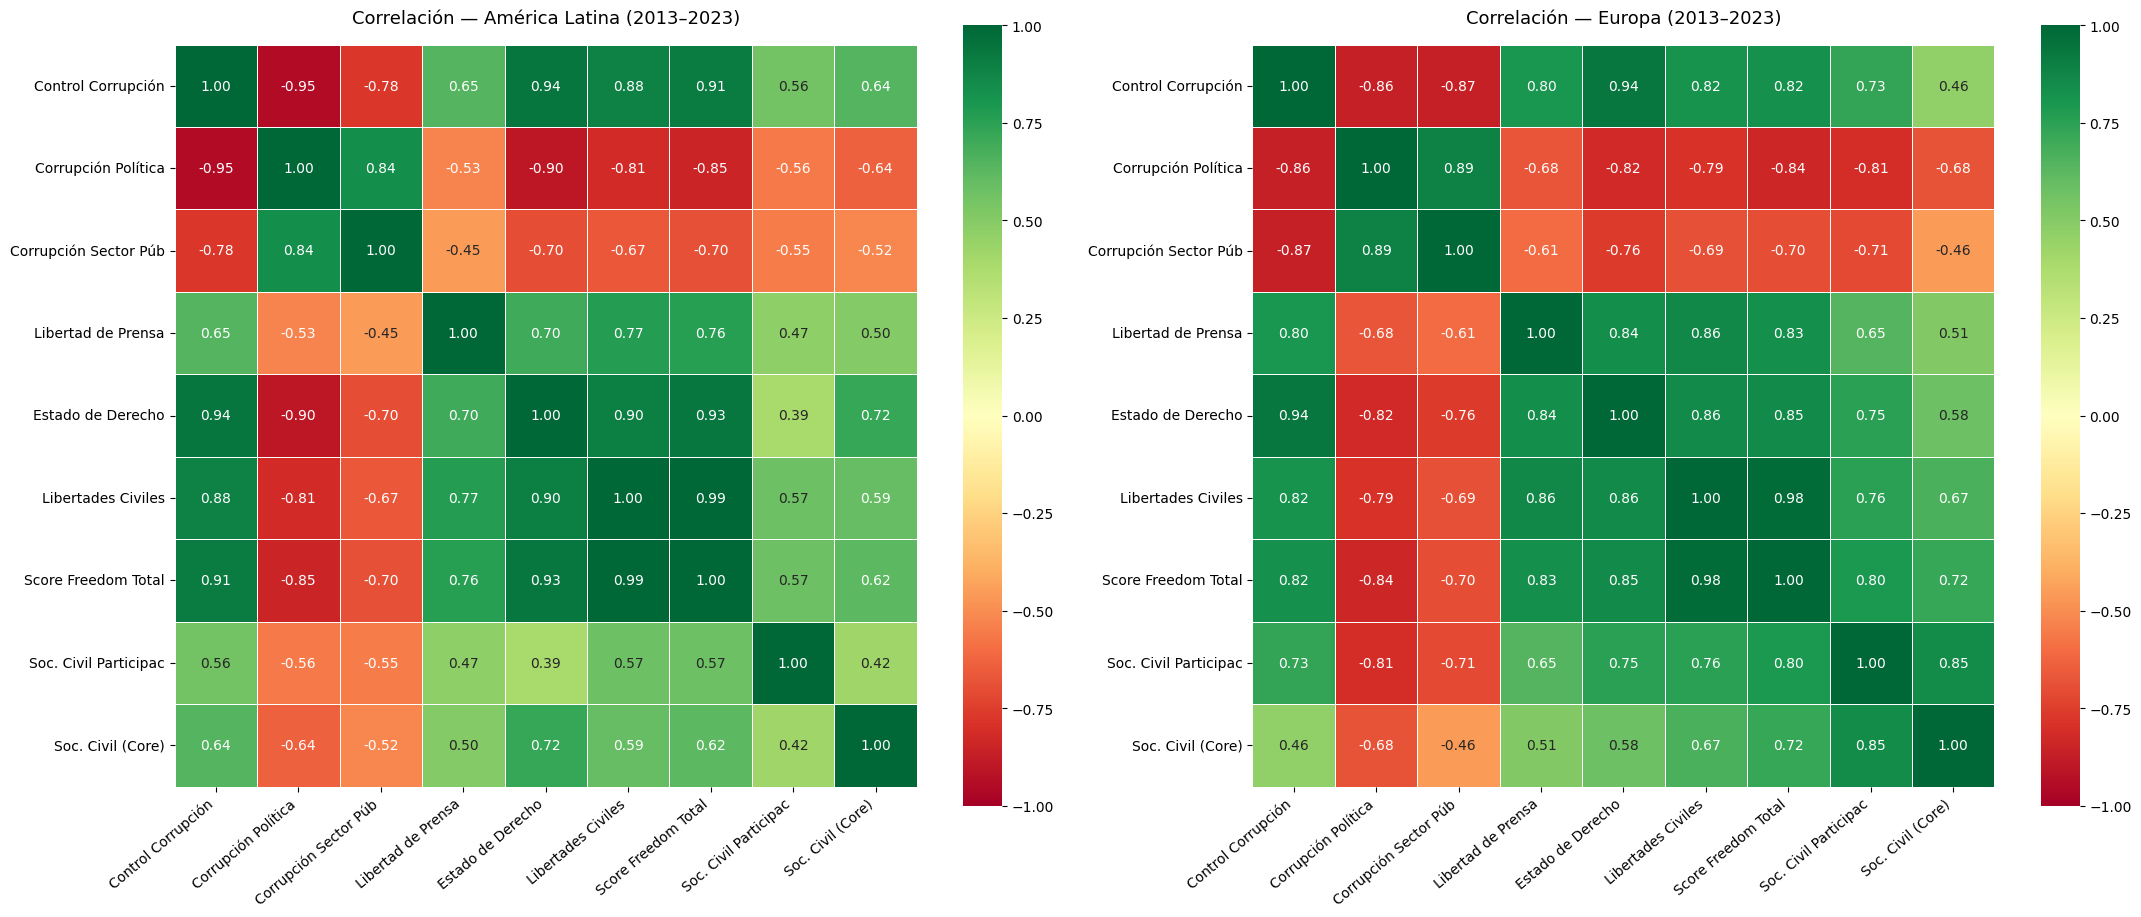

In [18]:
corr_eu = merged_eu_clean[list(INDICES.keys())].corr(method="pearson", min_periods=10)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, corr, titulo in zip(axes, [corr, corr_eu], ["América Latina", "Europa"]):
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="RdYlGn",
        center=0, vmin=-1, vmax=1,
        linewidths=0.5,
        square=True,
        ax=ax
    )
    ax.set_title(f"Correlación — {titulo} (2013–2023)", fontsize=13, pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

plt.tight_layout()
plt.show()

### **Ahora probamos algunas visualizaciones en D3js... la primera, el indice de control de corrupción de Argentina en contraste con el resto de los países de la región.**

In [20]:
import json

# ── 1. generamos el JSON con los datos reales ──────────────────────────────────
INDICES_CLAVE = [
    "Control Corrupción", "Estado de Derecho",
    "Score Freedom Total", "Libertad de Prensa", "Soc. Civil (Core)"
]
NOMBRES = {
    "ARG":"Argentina","BRA":"Brasil","CHL":"Chile","URY":"Uruguay",
    "PRY":"Paraguay","BOL":"Bolivia","PER":"Perú","COL":"Colombia","MEX":"México"
}

data_export = {}
for idx in INDICES_CLAVE:
    sub = merged_clean[["REF_AREA","TIME_PERIOD",idx]].dropna()
    anio = int(sub.groupby("REF_AREA")["TIME_PERIOD"].max().min())
    sub = sub[sub["TIME_PERIOD"]==anio].copy()
    media = float(sub[idx].mean())
    sub["desviacion"] = (sub[idx] - media).round(4)
    sub["valor"] = sub[idx].round(4)
    sub["pais"] = sub["REF_AREA"].map(NOMBRES)
    data_export[idx] = {
        "anio": anio, "media": round(media,4),
        "datos": sub[["REF_AREA","pais","valor","desviacion"]].to_dict(orient="records")
    }

DATA_JSON = json.dumps(data_export, ensure_ascii=False, indent=2)

# ── 2. armamos el HTML completo ─────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Pilar Institucional — América Latina</title>
  <style>
    body {{ font-family: system-ui, sans-serif; max-width: 780px; margin: 40px auto; padding: 0 24px; color: #1a1a1a; }}
    h1 {{ font-size: 18px; font-weight: 500; margin-bottom: 4px; }}
    p.sub {{ font-size: 13px; color: #666; margin-top: 0; margin-bottom: 24px; }}
    select {{ font-size: 13px; padding: 5px 10px; border: 1px solid #ccc; border-radius: 6px; cursor: pointer; }}
    .legend {{ display: flex; gap: 16px; margin-top: 10px; font-size: 12px; color: #555; flex-wrap: wrap; }}
    .legend span {{ display: flex; align-items: center; gap: 5px; }}
    .swatch {{ width: 10px; height: 10px; border-radius: 2px; display: inline-block; }}
    #anio {{ font-size: 12px; color: #888; margin-left: auto; }}
    #tooltip {{ position: fixed; pointer-events: none; opacity: 0; background: rgba(255,255,255,0.97);
                border: 1px solid #ddd; border-radius: 8px; padding: 8px 12px;
                font-size: 12px; line-height: 1.75; box-shadow: 0 2px 8px rgba(0,0,0,0.1); }}
  </style>
</head>
<body>
  <h1>Pilar institucional — América Latina (2013–2023)</h1>
  <p class="sub">Desviación de cada país respecto a la media regional. Fuentes: WGI, WJP, Freedom House, RSF, V-Dem.</p>

  <div style="display:flex;align-items:center;gap:12px;flex-wrap:wrap;margin-bottom:16px;">
    <label for="sel" style="font-size:13px;color:#555;">Índice</label>
    <select id="sel"></select>
    <span id="anio"></span>
  </div>

  <div id="chart" style="position:relative;width:100%;"></div>

  <div class="legend">
    <span><span class="swatch" style="background:#1D9E75;"></span>sobre la media</span>
    <span><span class="swatch" style="background:#D85A30;"></span>bajo la media</span>
    <span><span class="swatch" style="background:#378ADD;"></span>Argentina</span>
  </div>

  <div id="tooltip"></div>

  <script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
  <script>
    const DATA = {DATA_JSON};

    const sel = document.getElementById('sel');
    Object.keys(DATA).forEach(k => {{
      const o = document.createElement('option');
      o.value = k; o.textContent = k; sel.appendChild(o);
    }});

    const C_POS='#1D9E75', C_NEG='#D85A30', C_ARG='#378ADD';
    const ml=110, mr=80, mt=22, mb=36, barH=36, bw=560;
    const nRows = 9;
    const totalH = nRows*barH + mt + mb;

    const svg = d3.select('#chart').append('svg')
      .attr('viewBox',`0 0 ${{bw+ml+mr}} ${{totalH}}`)
      .attr('width','100%').style('overflow','visible');
    const g = svg.append('g').attr('transform',`translate(${{ml}},${{mt}})`);

    const xSc = d3.scaleLinear().range([0,bw]);
    const ySc = d3.scaleBand().range([0,nRows*barH]).padding(0.28);

    const xAxisG = g.append('g');
    const zLine  = g.append('line').attr('stroke','rgba(0,0,0,0.25)').attr('stroke-width',1);
    const avgTxt = g.append('text').attr('font-size',10).attr('fill','#888').attr('text-anchor','middle').attr('dy',-6);
    const barsG  = g.append('g');
    const lblG   = g.append('g');
    const valG   = g.append('g');
    const tip    = document.getElementById('tooltip');

    function fmt(v){{ return Math.abs(v)>=10?v.toFixed(1):Math.abs(v)>=1?v.toFixed(2):v.toFixed(3); }}

    function update(key){{
      const d = DATA[key];
      const sorted = [...d.datos].sort((a,b)=>b.desviacion-a.desviacion);
      const mx = Math.max(...sorted.map(r=>Math.abs(r.desviacion)))*1.22;
      xSc.domain([-mx,mx]); ySc.domain(sorted.map(r=>r.REF_AREA));
      document.getElementById('anio').textContent = 'año: ' + d.anio;
      const z = xSc(0);

      zLine.attr('x1',z).attr('x2',z).attr('y1',0).attr('y2',nRows*barH);
      avgTxt.attr('x',z).text('media regional');

      xAxisG.attr('transform',`translate(0,${{nRows*barH}})`)
        .call(d3.axisBottom(xSc).ticks(6).tickFormat(v=>(v>0?'+':'')+fmt(v)))
        .call(a=>a.select('.domain').attr('stroke','#ddd'))
        .call(a=>a.selectAll('.tick line').attr('stroke','#ddd'))
        .call(a=>a.selectAll('text').attr('fill','#888').attr('font-size',11));

      const bars = barsG.selectAll('rect').data(sorted,r=>r.REF_AREA);
      bars.enter().append('rect').attr('rx',3)
        .attr('y',r=>ySc(r.REF_AREA)).attr('height',ySc.bandwidth())
        .attr('x',z).attr('width',0)
        .on('mousemove',(ev,r)=>{{
          tip.style.opacity=1;
          tip.style.left=(ev.clientX+14)+'px'; tip.style.top=(ev.clientY-8)+'px';
          tip.innerHTML=`<strong>${{r.pais}}</strong><br>Valor: ${{fmt(r.valor)}}<br>Desviación: ${{r.desviacion>=0?'+':''}}${{fmt(r.desviacion)}}<br>Media: ${{fmt(d.media)}}`;
        }})
        .on('mouseleave',()=>tip.style.opacity=0)
        .merge(bars).transition().duration(550).ease(d3.easeCubicOut)
        .attr('fill',r=>r.REF_AREA==='ARG'?C_ARG:r.desviacion>=0?C_POS:C_NEG)
        .attr('y',r=>ySc(r.REF_AREA)).attr('height',ySc.bandwidth())
        .attr('x',r=>r.desviacion<0?xSc(r.desviacion):z)
        .attr('width',r=>Math.abs(xSc(r.desviacion)-z));
      bars.exit().remove();

      const lbls = lblG.selectAll('text').data(sorted,r=>r.REF_AREA);
      lbls.enter().append('text').attr('dominant-baseline','middle').attr('text-anchor','end')
        .merge(lbls).transition().duration(550)
        .attr('x',-8).attr('y',r=>ySc(r.REF_AREA)+ySc.bandwidth()/2)
        .attr('font-size',13).attr('font-weight',r=>r.REF_AREA==='ARG'?600:400)
        .attr('fill',r=>r.REF_AREA==='ARG'?C_ARG:'#222')
        .text(r=>r.pais);
      lbls.exit().remove();

      const vals = valG.selectAll('text').data(sorted,r=>r.REF_AREA);
      vals.enter().append('text').attr('dominant-baseline','middle')
        .merge(vals).transition().duration(550)
        .attr('y',r=>ySc(r.REF_AREA)+ySc.bandwidth()/2)
        .attr('x',r=>r.desviacion>=0?xSc(r.desviacion)+5:xSc(r.desviacion)-5)
        .attr('text-anchor',r=>r.desviacion>=0?'start':'end')
        .attr('font-size',11).attr('fill','#888')
        .text(r=>(r.desviacion>0?'+':'')+fmt(r.desviacion));
      vals.exit().remove();
    }}

    update(Object.keys(DATA)[0]);
    sel.addEventListener('change',e=>update(e.target.value));
  </script>
</body>
</html>"""

# ── 3. guardar en el parent ─────────────────────────────────────────
output_path = "/content/wb_data_vis-main/pilar_institucional.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Guardado en:", output_path)

✅ Guardado en: /content/wb_data_vis-main/pilar_institucional.html


### **Probando ahora BAR CHART RACE de D3JS con el indice Control de Corrupción (WGI Percentile Rank)...este es el que mas me interesa**

In [21]:
import pandas as pd
import json
from pathlib import Path

BASE = Path("/content/wb_data_vis-main/data/raw")

PAISES_INFO = {
    "ARG": ["Argentina",  "LATAM"],  "BOL": ["Bolivia",    "LATAM"],
    "BRA": ["Brasil",     "LATAM"],  "CHL": ["Chile",      "LATAM"],
    "COL": ["Colombia",   "LATAM"],  "MEX": ["México",     "LATAM"],
    "PRY": ["Paraguay",   "LATAM"],  "PER": ["Perú",       "LATAM"],
    "URY": ["Uruguay",    "LATAM"],  "DEU": ["Alemania",   "Europa"],
    "FRA": ["Francia",    "Europa"], "ESP": ["España",     "Europa"],
    "ITA": ["Italia",     "Europa"], "PRT": ["Portugal",   "Europa"],
    "SWE": ["Suecia",     "Europa"], "NOR": ["Noruega",    "Europa"],
    "DNK": ["Dinamarca",  "Europa"], "FIN": ["Finlandia",  "Europa"],
    "NLD": ["P. Bajos",   "Europa"], "AUT": ["Austria",    "Europa"],
    "GBR": ["R. Unido",   "Europa"], "BEL": ["Bélgica",    "Europa"],
    "POL": ["Polonia",    "Europa"], "HUN": ["Hungría",    "Europa"],
    "CZE": ["Rep. Checa", "Europa"], "ROU": ["Rumanía",    "Europa"],
    "GRC": ["Grecia",     "Europa"], "HRV": ["Croacia",    "Europa"],
    "SVN": ["Eslovenia",  "Europa"], "USA": ["EE.UU.",     "USA"],
    "RUS": ["Rusia",      "Rusia"],  "CHN": ["China",      "China"],
    "IND": ["India",      "India"],
}

# Cargar y limpiar
df = pd.read_parquet(BASE / "corruption/control_corruption:_percentile_rank.parquet")
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
df = df.dropna(subset=["OBS_VALUE"])
df["TIME_PERIOD"] = df["TIME_PERIOD"].astype(int)
df = df[df["REF_AREA"].isin(PAISES_INFO.keys())]
df = df.groupby(["REF_AREA","TIME_PERIOD"], as_index=False)["OBS_VALUE"].mean()

all_years = sorted(df["TIME_PERIOD"].unique().tolist())
print(f"Años disponibles ({len(all_years)}): {all_years}")

# Construir estructura por país
raw_data = []
for iso, (nombre, region) in PAISES_INFO.items():
    sub = df[df["REF_AREA"]==iso].set_index("TIME_PERIOD")["OBS_VALUE"]
    valores = {int(y): round(float(v), 2) for y, v in sub.items()}
    if valores:
        raw_data.append({"nombre": nombre, "region": region, "valores": valores})
        print(f"✅ {nombre}: {len(valores)} años ({min(valores)}-{max(valores)})")
    else:
        print(f"⚠️  Sin datos: {nombre} ({iso})")

# Generar JS
js = f"const KEY_YEARS = {json.dumps(all_years)};\n\n"
js += f"const RAW_DATA = {json.dumps(raw_data, ensure_ascii=False, indent=2)};"

output = "/content/wb_data_vis-main/race_data.js"
with open(output, "w", encoding="utf-8") as f:
    f.write(js)

print(f"\n✅ Guardado en {output}")
print(f"Total países exportados: {len(raw_data)}")

Años disponibles (25): [1996, 1998, 2000, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
✅ Argentina: 25 años (1996-2023)
✅ Bolivia: 25 años (1996-2023)
✅ Brasil: 25 años (1996-2023)
✅ Chile: 25 años (1996-2023)
✅ Colombia: 25 años (1996-2023)
✅ México: 25 años (1996-2023)
✅ Paraguay: 25 años (1996-2023)
✅ Perú: 25 años (1996-2023)
✅ Uruguay: 25 años (1996-2023)
✅ Alemania: 25 años (1996-2023)
✅ Francia: 25 años (1996-2023)
✅ España: 25 años (1996-2023)
✅ Italia: 25 años (1996-2023)
✅ Portugal: 25 años (1996-2023)
✅ Suecia: 25 años (1996-2023)
✅ Noruega: 25 años (1996-2023)
✅ Dinamarca: 25 años (1996-2023)
✅ Finlandia: 25 años (1996-2023)
✅ P. Bajos: 25 años (1996-2023)
✅ Austria: 25 años (1996-2023)
✅ R. Unido: 25 años (1996-2023)
✅ Bélgica: 25 años (1996-2023)
✅ Polonia: 25 años (1996-2023)
✅ Hungría: 25 años (1996-2023)
✅ Rep. Checa: 25 años (1996-2023)
✅ Rumanía: 25 años (1996-2023)
✅ Grecia: 25 añ

In [24]:
import pandas as pd
import json
from pathlib import Path

BASE = Path("/content/wb_data_vis-main/data/raw")

PAISES_INFO = {
    "ARG": ["Argentina",  "LATAM"],  "BOL": ["Bolivia",    "LATAM"],
    "BRA": ["Brasil",     "LATAM"],  "CHL": ["Chile",      "LATAM"],
    "COL": ["Colombia",   "LATAM"],  "MEX": ["México",     "LATAM"],
    "PRY": ["Paraguay",   "LATAM"],  "PER": ["Perú",       "LATAM"],
    "URY": ["Uruguay",    "LATAM"],  "DEU": ["Alemania",   "Europa"],
    "FRA": ["Francia",    "Europa"], "ESP": ["España",     "Europa"],
    "ITA": ["Italia",     "Europa"], "PRT": ["Portugal",   "Europa"],
    "SWE": ["Suecia",     "Europa"], "NOR": ["Noruega",    "Europa"],
    "DNK": ["Dinamarca",  "Europa"], "FIN": ["Finlandia",  "Europa"],
    "NLD": ["P. Bajos",   "Europa"], "AUT": ["Austria",    "Europa"],
    "GBR": ["R. Unido",   "Europa"], "BEL": ["Bélgica",    "Europa"],
    "POL": ["Polonia",    "Europa"], "HUN": ["Hungría",    "Europa"],
    "CZE": ["Rep. Checa", "Europa"], "ROU": ["Rumanía",    "Europa"],
    "GRC": ["Grecia",     "Europa"], "HRV": ["Croacia",    "Europa"],
    "SVN": ["Eslovenia",  "Europa"], "USA": ["EE.UU.",     "USA"],
    "RUS": ["Rusia",      "Rusia"],  "CHN": ["China",      "China"],
    "IND": ["India",      "India"],
}

# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_parquet(BASE / "corruption/control_corruption:_percentile_rank.parquet")
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
df = df.dropna(subset=["OBS_VALUE"])
df["TIME_PERIOD"] = df["TIME_PERIOD"].astype(int)
df = df[df["REF_AREA"].isin(PAISES_INFO.keys())]
df = df.groupby(["REF_AREA","TIME_PERIOD"], as_index=False)["OBS_VALUE"].mean()

all_years = sorted(df["TIME_PERIOD"].unique().tolist())
raw_data = []
for iso, (nombre, region) in PAISES_INFO.items():
    sub = df[df["REF_AREA"]==iso].set_index("TIME_PERIOD")["OBS_VALUE"]
    valores = {int(y): round(float(v), 2) for y, v in sub.items()}
    if valores:
        raw_data.append({"nombre": nombre, "region": region, "valores": valores})

KEY_YEARS_JS = json.dumps(all_years)
RAW_DATA_JS  = json.dumps(raw_data, ensure_ascii=False, indent=2)
YEAR_START   = all_years[0]
YEAR_END     = all_years[-1]

# ── HTML completo ─────────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Control de Corrupción — Bar Chart Race</title>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ font-family: system-ui, sans-serif; background: #fff; color: #1a1a1a; padding: 28px 32px; max-width: 760px; }}
    h1 {{ font-size: 17px; font-weight: 500; margin-bottom: 4px; }}
    p.sub {{ font-size: 12px; color: #888; margin-bottom: 16px; }}
    .legend {{ display: flex; gap: 14px; flex-wrap: wrap; font-size: 11px; color: #555; margin-bottom: 12px; }}
    .legend span {{ display: flex; align-items: center; gap: 4px; }}
    .swatch {{ width: 9px; height: 9px; border-radius: 2px; display: inline-block; }}
    .controls {{ display: flex; align-items: center; gap: 10px; margin-top: 12px; flex-wrap: wrap; }}
    button {{ font-size: 12px; padding: 5px 14px; border: 1px solid #ccc; border-radius: 6px; background: #fff; cursor: pointer; }}
    button:hover {{ background: #f5f5f5; }}
    label {{ font-size: 12px; color: #666; }}
    input[type=range] {{ width: 80px; }}
  </style>
</head>
<body>
  <h1>Control de Corrupción — WGI Percentile Rank</h1>
  <p class="sub">0 = más corrupto · 100 = menos corrupto · Fuente: Worldwide Governance Indicators, Banco Mundial</p>

  <div class="legend">
    <span><span class="swatch" style="background:#378ADD;"></span>Europa</span>
    <span><span class="swatch" style="background:#EF9F27;"></span>EE.UU.</span>
    <span><span class="swatch" style="background:#D85A30;"></span>América Latina</span>
    <span><span class="swatch" style="background:#E24B4A;"></span>China</span>
    <span><span class="swatch" style="background:#BA7517;"></span>India</span>
    <span><span class="swatch" style="background:#888780;"></span>Rusia</span>
  </div>

  <div id="race" style="position:relative;width:100%;"></div>

  <div class="controls">
    <button id="btn-play">⏸ Pausar</button>
    <label>Velocidad</label>
    <input type="range" id="speed" min="1" max="5" value="3" step="1">
    <button id="btn-restart">↺ Reiniciar</button>
  </div>

  <script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
  <script>
    const KEY_YEARS = {KEY_YEARS_JS};
    const RAW_DATA  = {RAW_DATA_JS};

    const COLORS = {{Europa:"#378ADD",USA:"#EF9F27",LATAM:"#D85A30",China:"#E24B4A",India:"#BA7517",Rusia:"#888780"}};

    function interp(valores, year) {{
      const years = Object.keys(valores).map(Number).sort((a,b)=>a-b);
      if (year <= years[0]) return valores[years[0]];
      if (year >= years[years.length-1]) return valores[years[years.length-1]];
      for (let i=0; i<years.length-1; i++) {{
        if (year >= years[i] && year <= years[i+1]) {{
          const t = (year-years[i])/(years[i+1]-years[i]);
          return valores[years[i]] + t*(valores[years[i+1]]-valores[years[i]]);
        }}
      }}
    }}

    const N=15, BAR=28, GAP=6, SLOT=BAR+GAP;
    const ML=112, MR=52, MT=26, MB=8, BAR_W=480;
    const W=ML+BAR_W+MR, H=MT+N*SLOT+MB;
    const xSc = d3.scaleLinear().domain([0,100]).range([0,BAR_W]);

    const wrap = document.getElementById('race');
    const svg  = d3.select(wrap).append('svg')
      .attr('viewBox',`0 0 ${{W}} ${{H}}`).attr('width','100%');
    const root = svg.append('g').attr('transform',`translate(${{ML}},${{MT}})`);

    [25,50,75,100].forEach(v=>{{
      root.append('line').attr('x1',xSc(v)).attr('x2',xSc(v))
        .attr('y1',0).attr('y2',N*SLOT).attr('stroke','rgba(0,0,0,0.07)').attr('stroke-width',0.5);
      root.append('text').attr('x',xSc(v)).attr('y',-6)
        .attr('text-anchor','middle').attr('font-size',9).attr('fill','#aaa').text(v);
    }});

    const barsG   = root.append('g');
    const yearTxt = svg.append('text')
      .attr('x',W-MR+8).attr('y',MT+N*SLOT-8)
      .attr('text-anchor','end').attr('font-size',52).attr('font-weight',500)
      .attr('fill','rgba(0,0,0,0.10)').text(KEY_YEARS[0]);

    function getFrameVals(year) {{
      return RAW_DATA
        .map((d) => ({{name: d.nombre, region: d.region, value: interp(d.valores, year)}}))
        .sort((a,b)=>b.value-a.value).slice(0,N)
        .map((d,i)=>({{...d, rank:i}}));
    }}

    function update(year) {{
      const dur = msPerFrame * 0.82;
      const top = getFrameVals(year);
      yearTxt.text(Math.floor(year));

      const bg  = barsG.selectAll('g.rw').data(top, d=>d.name);
      const ent = bg.enter().append('g').attr('class','rw')
        .attr('transform',`translate(0,${{N*SLOT}})`).style('opacity',0);

      ent.append('rect').attr('class','br').attr('height',BAR).attr('rx',3).attr('width',0);
      ent.append('text').attr('class','ln').attr('text-anchor','end')
        .attr('x',-7).attr('y',BAR/2).attr('dominant-baseline','middle').attr('font-size',11.5);
      ent.append('text').attr('class','vn')
        .attr('y',BAR/2).attr('dominant-baseline','middle').attr('x',4).attr('font-size',10.5);

      bg.exit().transition().duration(dur*2)
        .attr('transform',`translate(0,${{N*SLOT}})`).style('opacity',0).remove();

      const all = ent.merge(bg);
      all.transition().duration(dur).ease(d3.easeLinear)
        .attr('transform',d=>`translate(0,${{d.rank*SLOT}})`).style('opacity',1);

      all.select('.br').attr('fill',d=>COLORS[d.region])
        .attr('opacity',d=>d.name==='Argentina'?1:0.82)
        .transition().duration(dur).ease(d3.easeLinear)
        .attr('width',d=>xSc(d.value));

      all.select('.ln')
        .attr('fill',d=>d.name==='Argentina'?COLORS.LATAM:'rgba(0,0,0,0.78)')
        .attr('font-weight',d=>d.name==='Argentina'?600:400)
        .text(d=>d.name==='Argentina'?'★ Argentina':d.name);

      all.select('.vn').attr('fill','rgba(0,0,0,0.42)')
        .transition().duration(dur).ease(d3.easeLinear)
        .attr('x',d=>xSc(d.value)+5)
        .tween('text',function(d){{
          const prev=+this.getAttribute('data-v')||d.value;
          this.setAttribute('data-v',d.value);
          const fi=d3.interpolateNumber(prev,d.value);
          return t=>{{ this.textContent=fi(t).toFixed(1); }};
        }});
    }}

    let currentYear = KEY_YEARS[0];
    let msPerFrame  = 80;
    let timer = null;
    let running = true;
    const YEAR_END = KEY_YEARS[KEY_YEARS.length-1];

    function tick() {{
      currentYear += 1/12;
      if (currentYear >= YEAR_END) {{
        currentYear = YEAR_END;
        update(currentYear);
        pause();
        document.getElementById('btn-play').textContent = '▶ Reproducir';
        return;
      }}
      update(currentYear);
    }}

    function play()  {{ if(timer) return; timer=setInterval(tick,msPerFrame); running=true; }}
    function pause() {{ if(timer){{ clearInterval(timer); timer=null; }} running=false; }}

    document.getElementById('btn-play').addEventListener('click',function(){{
      if(running){{ pause(); this.textContent='▶ Reproducir'; }}
      else {{ play(); this.textContent='⏸ Pausar'; }}
    }});
    document.getElementById('btn-restart').addEventListener('click',function(){{
      pause(); currentYear=KEY_YEARS[0]; update(currentYear);
      play(); document.getElementById('btn-play').textContent='⏸ Pausar';
    }});
    document.getElementById('speed').addEventListener('input',function(){{
      msPerFrame=[160,100,80,50,25][+this.value-1];
      if(running){{ pause(); play(); }}
    }});

    update(currentYear);
    play();
  </script>
</body>
</html>"""

output = "/content/wb_data_vis-main/bar_chart_race.html"
with open(output, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Guardado en: {output}")
print(f"   Años: {YEAR_START} → {YEAR_END}")
print(f"   Países: {len(raw_data)}")

✅ Guardado en: /content/wb_data_vis-main/bar_chart_race.html
   Años: 1996 → 2023
   Países: 33


In [26]:
##Fixeamos para que aparezca Argentina"

import re

path = "/content/wb_data_vis-main/bar_chart_race.html"
with open(path, "r", encoding="utf-8") as f:
    html = f.read()

# ── Fix 1: N=15 → N=20 para que aparezca Argentina ───────────────────────────
html = html.replace("const N=15,", "const N=20,")

# ── Fix 2: Color único por país ───────────────────────────────────────────────
PALETTE = [
    "#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f","#edc948","#b07aa1",
    "#ff9da7","#9c755f","#525252","#1f77b4","#ff7f0e","#2ca02c","#d62728",
    "#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf","#393b79",
    "#637939","#8c6d31","#843c39","#7b4173","#3182bd","#e6550d","#31a354",
    "#756bb1","#969696","#6baed6","#fd8d3c","#74c476"
]
nombres = re.findall(r'"nombre": "([^"]+)"', html)
color_map = {n: PALETTE[i % len(PALETTE)] for i, n in enumerate(nombres)}
color_js = "const COUNTRY_COLORS = {\n" + \
           ",\n".join(f'  "{k}": "{v}"' for k,v in color_map.items()) + "\n};"

html = html.replace(
    'const COLORS = {Europa:"#378ADD",USA:"#EF9F27",LATAM:"#D85A30",China:"#E24B4A",India:"#BA7517",Rusia:"#888780"};',
    f'const COLORS = {{Europa:"#378ADD",USA:"#EF9F27",LATAM:"#D85A30",China:"#E24B4A",India:"#BA7517",Rusia:"#888780"}};\n    {color_js}'
)

# ── Fix 3: Usar color por país en las barras ──────────────────────────────────
html = html.replace(
    "all.select('.br').attr('fill',d=>COLORS[d.region])",
    "all.select('.br').attr('fill',d=>COUNTRY_COLORS[d.name]||'#888')"
)

# ── Fix 4: Label de Argentina sin color especial (ya se distingue por ★) ──────
html = html.replace(
    ".attr('fill',d=>d.name==='Argentina'?COLORS.LATAM:'rgba(0,0,0,0.78)')",
    ".attr('fill','rgba(0,0,0,0.78)')"
)

# ── Fix 5: Actualizar leyenda con colores reales por país ─────────────────────
legend_items = "".join(
    f'<span><span class="swatch" style="background:{color_map[n]};"></span>{n}</span>'
    for n in nombres
)
new_legend = f'<div class="legend" style="font-size:10px;">{legend_items}</div>'
html = re.sub(r'<div class="legend">.*?</div>', new_legend, html, flags=re.DOTALL)

with open(path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Archivo actualizado:")
print(f"   · N = 20 barras visibles")
print(f"   · {len(color_map)} países con colores distintos")
print(f"   · Argentina: {color_map.get('Argentina', '?')}")

✅ Archivo actualizado:
   · N = 20 barras visibles
   · 33 países con colores distintos
   · Argentina: #4e79a7


In [28]:
##agregamos unas lineas para que ARGENTINA aparezca con la posicón que ocupa en el ranking cada año##

path = "/content/wb_data_vis-main/bar_chart_race.html"
with open(path, "r", encoding="utf-8") as f:
    html = f.read()

# Reemplazar getFrameVals para que Argentina siempre aparezca
old_fn = """    function getFrameVals(year) {
      return RAW_DATA
        .map((d) => ({name: d.nombre, region: d.region, value: interp(d.valores, year)}))
        .sort((a,b)=>b.value-a.value).slice(0,N)
        .map((d,i)=>({...d, rank:i}));
    }"""

new_fn = """    function getFrameVals(year) {
      const all = RAW_DATA
        .map((d) => ({name: d.nombre, region: d.region, value: interp(d.valores, year)}))
        .sort((a,b) => b.value - a.value);

      const top = all.slice(0, N);
      const argInTop = top.some(d => d.name === 'Argentina');

      if (!argInTop) {
        const arg = all.find(d => d.name === 'Argentina');
        top[N - 1] = { ...arg, forced: true };
      }

      return top.map((d, i) => ({ ...d, rank: i }));
    }"""

html = html.replace(old_fn, new_fn)

# Hacer que Argentina se vea distinta cuando está forzada (borde punteado + label con rank real)
old_label = """      all.select('.ln')
        .attr('fill','rgba(0,0,0,0.78)')
        .attr('font-weight',d=>d.name==='Argentina'?600:400)
        .text(d=>d.name==='Argentina'?'★ Argentina':d.name);"""

new_label = """      // Calcular rank real de Argentina para mostrarlo
      const allSorted = RAW_DATA
        .map(d => ({name: d.nombre, value: interp(d.valores, year)}))
        .sort((a,b) => b.value - a.value);
      const argRealRank = allSorted.findIndex(d => d.name === 'Argentina') + 1;

      all.select('.ln')
        .attr('fill', d => d.name === 'Argentina' ? '#D85A30' : 'rgba(0,0,0,0.78)')
        .attr('font-weight', d => d.name === 'Argentina' ? 600 : 400)
        .text(d => d.name === 'Argentina'
          ? (d.forced ? `★ Argentina (#${argRealRank})` : '★ Argentina')
          : d.name);

      all.select('.br')
        .style('outline', d => d.forced && d.name === 'Argentina' ? '2px dashed #D85A30' : 'none')
        .attr('opacity', d => d.forced && d.name === 'Argentina' ? 0.6 : (d.name === 'Argentina' ? 1 : 0.85));"""

html = html.replace(old_label, new_label)

# Guardar con nombre limpio
out = "/content/wb_data_vis-main/bar_chart_race.html"
with open(out, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Guardado en {out}")
print("   Argentina ahora aparece siempre.")
print("   Cuando está fuera del top real, se muestra con barra punteada y su rank real entre paréntesis.")

✅ Guardado en /content/wb_data_vis-main/bar_chart_race.html
   Argentina ahora aparece siempre.
   Cuando está fuera del top real, se muestra con barra punteada y su rank real entre paréntesis.
